<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Link :- https://colab.research.google.com/drive/1O0MeH9Jpp9Q_vo2pEIXRMKZGrt7mXtKy#scrollTo=AJnx3vOqfC8-

# Experiment 8: Build a CNN Architecture for Image Classification (MNIST)

---

##  Aim
To build a Convolutional Neural Network (CNN) from scratch using TensorFlow/Keras for image classification on the MNIST handwritten digit dataset, and understand each component of the CNN pipeline.

---

##  Theory

### What is a CNN?

A **Convolutional Neural Network (CNN)** is a type of deep learning model specifically designed to process **grid-like data** — most commonly images. Unlike a simple Fully Connected Network (FCN) where every neuron connects to every other, CNNs exploit the **spatial structure** of images using three key operations:

1. **Convolution**
2. **Activation (ReLU)**
3. **Pooling**

---

### Step 1: Convolution

A **convolution** is a mathematical operation where a small matrix called a **kernel** (or filter) slides over the input image and computes the **dot product** at each position.

$$\text{Output}[i,j] = \sum_{m} \sum_{n} \text{Image}[i+m, j+n] \times \text{Kernel}[m, n]$$

- The kernel detects a specific pattern (edge, corner, texture)
- Different kernels detect different features
- The output of this operation is called a **feature map**

**Example kernel types:**
- Vertical edge detector: `[[1,0,-1],[1,0,-1],[1,0,-1]]`
- Horizontal edge detector: `[[1,1,1],[0,0,0],[-1,-1,-1]]`
- Blur kernel: `[[1,1,1],[1,1,1],[1,1,1]] / 9`

**Key parameters:**
- **Kernel size**: Usually 3×3 or 5×5
- **Stride**: How many pixels the kernel moves at each step
- **Padding**: Adding zeros around the border to control output size

---

### Step 2: Activation Function — ReLU

After convolution, we apply **ReLU (Rectified Linear Unit)**:

$$\text{ReLU}(x) = \max(0, x)$$

- Replaces all negative values with 0
- Introduces **non-linearity** — without it, stacking layers is useless (all linear layers collapse to one)
- Simple and computationally efficient

---

### Step 3: Pooling

**Max Pooling** reduces the spatial size of the feature map:
- Divides the feature map into non-overlapping windows (e.g., 2×2)
- Takes the **maximum value** in each window
- Reduces computation and provides **translation invariance** (small shifts don't affect output)

A 28×28 image after a 2×2 max pool becomes 14×14 — 4× fewer pixels to process.

---

### Step 4: Flatten → Fully Connected → Softmax

After convolution and pooling, the 2D feature maps are **flattened** into a 1D vector. This vector is passed through **Dense (Fully Connected) layers** and finally a **Softmax** output layer:

$$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

Softmax converts raw scores into **probabilities** that sum to 1. The index with the highest probability is the predicted class.

---

### CNN Architecture Overview (for MNIST)

```
Input (28×28×1 grayscale image)
       ↓
Conv2D (32 filters, 3×3, ReLU)  → Feature map: 28×28×32
       ↓
MaxPool2D (2×2)                 → Feature map: 14×14×32
       ↓
Conv2D (64 filters, 3×3, ReLU)  → Feature map: 14×14×64
       ↓
MaxPool2D (2×2)                 → Feature map: 7×7×64
       ↓
Flatten                         → 3136-dim vector
       ↓
Dense (128 neurons, ReLU)       → 128-dim vector
       ↓
Dropout (0.5)                   → Regularization
       ↓
Dense (10 neurons, Softmax)     → 10 probabilities (digits 0–9)
```

---

### About the MNIST Dataset

- **MNIST** (Modified National Institute of Standards and Technology)
- 70,000 grayscale images of handwritten digits (0–9)
- Each image: 28×28 pixels, single channel
- 60,000 training images + 10,000 test images
- A classic benchmark for image classification models

---

### Loss Function: Sparse Categorical Cross-Entropy

$$L = -\sum_i y_i \log(\hat{y}_i)$$

Where $y_i$ is the true label (one-hot) and $\hat{y}_i$ is the predicted probability. We use `sparse_categorical_crossentropy` because our labels are integers (0–9), not one-hot encoded.

### Optimizer: Adam

**Adam (Adaptive Moment Estimation)** combines momentum and RMSProp. It adapts the learning rate for each parameter and converges faster than vanilla SGD.

---

## Part A: Manual Convolution from Scratch (No Library)

Before using TensorFlow/Keras, let's understand convolution manually — exactly how a CNN processes an image, step by step.

### Step 1: Load Dataset and Visualize a Sample Image

Dataset Info:
  Training samples: 60000
  Test samples    : 10000
  Image shape     : (28, 28)

Sample image label: 3 (digit shown is '3')
Pixel value range : [0.0, 1.0]


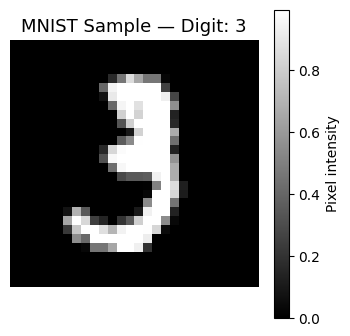

In [13]:
# Import core libraries
import numpy as np               # Numerical computing
import matplotlib.pyplot as plt  # Plotting and visualization
from keras.datasets import mnist # MNIST dataset

# Load MNIST data
# train_images: 60,000 images of shape (28, 28)
# train_labels: 60,000 integer labels (0-9)
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize pixel values from [0, 255] to [0, 1]
# This makes training more stable and faster
train_images = train_images / 255.0
test_images  = test_images  / 255.0

# Pick one sample image to work with (index 10)
image = train_images[10]
label = train_labels[10]

print("Dataset Info:")
print(f"  Training samples: {train_images.shape[0]}")
print(f"  Test samples    : {test_images.shape[0]}")
print(f"  Image shape     : {train_images.shape[1:]}")
print(f"\nSample image label: {label} (digit shown is '{label}')")
print(f"Pixel value range : [{image.min():.1f}, {image.max():.1f}]")

# Display the sample image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title(f"MNIST Sample — Digit: {label}", fontsize=13)
plt.colorbar(label='Pixel intensity')
plt.axis('off')
plt.show()

### Step 2: Define Kernels and Understand Their Effect

**Theory:** A kernel is a small weight matrix. The CNN **learns** the best kernels during training. But we can manually define kernels to see what kinds of features they detect.

In [14]:
# Define different types of kernels (filters) used in CNNs

# Vertical edge detector — responds to vertical lines
kernel_vertical = np.array([
    [1,  0, -1],
    [1,  0, -1],
    [1,  0, -1]
])

# Horizontal edge detector — responds to horizontal lines
kernel_horizontal = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
])

# Sharpening kernel — enhances edges and details
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Blur kernel — smoothens the image
kernel_blur = np.ones((3, 3)) / 9.0

print("Vertical Edge Kernel:")
print(kernel_vertical)
print("\nHorizontal Edge Kernel:")
print(kernel_horizontal)
print("\nSharpening Kernel:")
print(kernel_sharpen)

Vertical Edge Kernel:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Horizontal Edge Kernel:
[[ 1  1  1]
 [ 0  0  0]
 [-1 -1 -1]]

Sharpening Kernel:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


### Step 3: Manual Convolution — Debug Mode (Small Example)

**Theory:** Let's trace through convolution on a tiny 5×5 image to see exactly what happens at each position.

In [15]:
# Small 5x5 image for easy manual tracing
small_image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 2, 1, 0, 0],
    [5, 2, 3, 1, 1],
    [2, 1, 0, 1, 3]
])

# Simple kernel
small_kernel = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 1]
])

print("Image (5x5):")
print(small_image)
print("\nKernel (3x3):")
print(small_kernel)

def convolve_debug(image, kernel, max_debug=4):
    """
    Perform 2D convolution with step-by-step debugging.
    Shows first `max_debug` positions in detail.
    """
    h, w = image.shape
    k = kernel.shape[0]

    # Output size: (h - k + 1) x (w - k + 1) for 'valid' convolution (no padding)
    output = np.zeros((h - k + 1, w - k + 1))

    count = 0
    for i in range(h - k + 1):
        for j in range(w - k + 1):

            # Extract the patch of the image that aligns with the kernel
            patch = image[i:i+k, j:j+k]

            # Element-wise multiplication
            multiplied = patch * kernel

            # Sum all elements to get scalar output
            result = np.sum(multiplied)
            output[i, j] = result

            # Print debug info for first few positions only
            if count < max_debug:
                print(f"\n{'='*40}")
                print(f"Kernel at position ({i},{j}):")
                print(f"  Patch:\n{patch}")
                print(f"  Kernel × Patch:\n{multiplied}")
                print(f"  Sum (output[{i},{j}]) = {result}")
            count += 1

    print(f"\n... ({count - max_debug} more positions computed)")
    return output

# Run the debug convolution
conv_result = convolve_debug(small_image, small_kernel, max_debug=3)
print("\nFull Convolution Output (3x3):")
print(conv_result)

Image (5x5):
[[1 2 3 0 1]
 [0 1 2 3 1]
 [1 2 1 0 0]
 [5 2 3 1 1]
 [2 1 0 1 3]]

Kernel (3x3):
[[1 1 0]
 [0 1 1]
 [1 0 1]]

Kernel at position (0,0):
  Patch:
[[1 2 3]
 [0 1 2]
 [1 2 1]]
  Kernel × Patch:
[[1 2 0]
 [0 1 2]
 [1 0 1]]
  Sum (output[0,0]) = 8

Kernel at position (0,1):
  Patch:
[[2 3 0]
 [1 2 3]
 [2 1 0]]
  Kernel × Patch:
[[2 3 0]
 [0 2 3]
 [2 0 0]]
  Sum (output[0,1]) = 12

Kernel at position (0,2):
  Patch:
[[3 0 1]
 [2 3 1]
 [1 0 0]]
  Kernel × Patch:
[[3 0 0]
 [0 3 1]
 [1 0 0]]
  Sum (output[0,2]) = 8

... (6 more positions computed)

Full Convolution Output (3x3):
[[ 8. 12.  8.]
 [12.  7.  9.]
 [10.  9.  6.]]


### Step 4: Apply Different Kernels to the MNIST Image

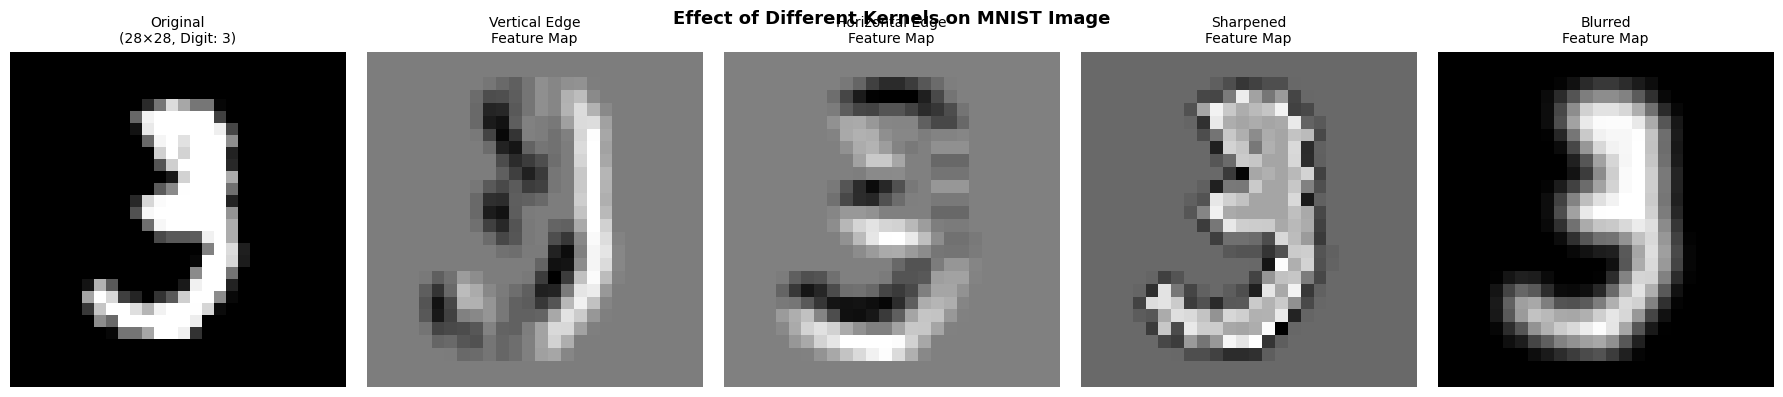


Observation:
  Vertical Edge: Highlights vertical strokes in the digit
  Horizontal Edge: Highlights horizontal strokes
  Sharpen: Makes edges much more prominent
  Blur: Smoothens the image, losing fine details


In [16]:
def convolve(image, kernel):
    """Clean convolution function (no debug prints) for full MNIST image."""
    h, w = image.shape
    k = kernel.shape[0]
    output = np.zeros((h - k + 1, w - k + 1))

    for i in range(h - k + 1):
        for j in range(w - k + 1):
            patch = image[i:i+k, j:j+k]
            output[i, j] = np.sum(patch * kernel)

    return output

# Apply all kernels to the MNIST sample image
feature_vertical   = convolve(image, kernel_vertical)
feature_horizontal = convolve(image, kernel_horizontal)
feature_sharpen    = convolve(image, kernel_sharpen)
feature_blur       = convolve(image, kernel_blur)

# Visualize: original + 4 feature maps
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title(f"Original\n(28×28, Digit: {label})", fontsize=10)
axes[0].axis('off')

axes[1].imshow(feature_vertical, cmap='gray')
axes[1].set_title("Vertical Edge\nFeature Map", fontsize=10)
axes[1].axis('off')

axes[2].imshow(feature_horizontal, cmap='gray')
axes[2].set_title("Horizontal Edge\nFeature Map", fontsize=10)
axes[2].axis('off')

axes[3].imshow(feature_sharpen, cmap='gray')
axes[3].set_title("Sharpened\nFeature Map", fontsize=10)
axes[3].axis('off')

axes[4].imshow(feature_blur, cmap='gray')
axes[4].set_title("Blurred\nFeature Map", fontsize=10)
axes[4].axis('off')

plt.suptitle("Effect of Different Kernels on MNIST Image", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservation:")
print("  Vertical Edge: Highlights vertical strokes in the digit")
print("  Horizontal Edge: Highlights horizontal strokes")
print("  Sharpen: Makes edges much more prominent")
print("  Blur: Smoothens the image, losing fine details")

### Step 5: ReLU Activation

**Theory:** ReLU removes negative values. In terms of images, this means removing "negative responses" from the kernel — keeping only the positive activations (where the kernel matched the image pattern strongly).

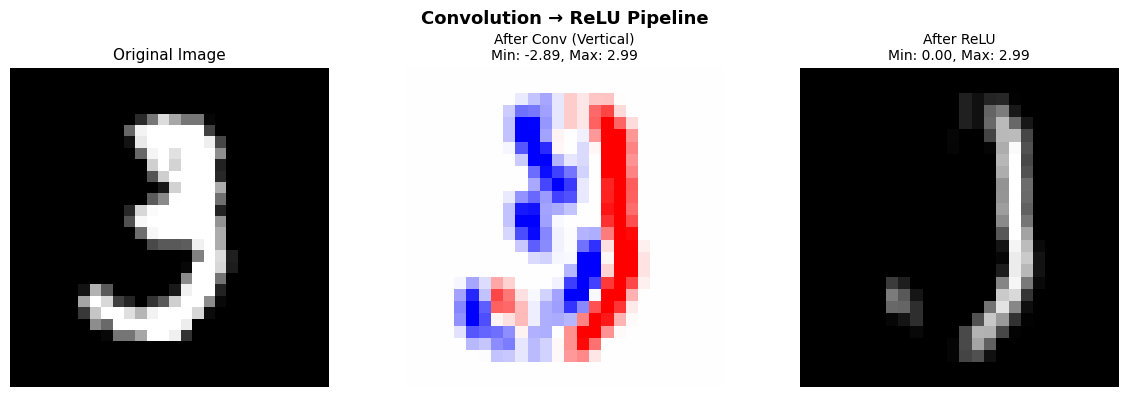

ReLU removes negative values — only positive feature responses are kept.
Values below 0 before ReLU: 134 pixels
Values below 0 after ReLU : 0 pixels (should be 0)


In [17]:
# Apply ReLU to the vertical edge feature map
# np.maximum(0, x) replaces all negative values with 0
relu_output = np.maximum(0, feature_vertical)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original image
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image", fontsize=11)
axes[0].axis('off')

# Feature map before ReLU (has negative values)
axes[1].imshow(feature_vertical, cmap='bwr', vmin=-2, vmax=2)  # bwr = blue-white-red
axes[1].set_title(f"After Conv (Vertical)\nMin: {feature_vertical.min():.2f}, Max: {feature_vertical.max():.2f}", fontsize=10)
axes[1].axis('off')

# Feature map after ReLU (only positive values)
axes[2].imshow(relu_output, cmap='gray')
axes[2].set_title(f"After ReLU\nMin: {relu_output.min():.2f}, Max: {relu_output.max():.2f}", fontsize=10)
axes[2].axis('off')

plt.suptitle("Convolution → ReLU Pipeline", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("ReLU removes negative values — only positive feature responses are kept.")
print(f"Values below 0 before ReLU: {(feature_vertical < 0).sum()} pixels")
print(f"Values below 0 after ReLU : {(relu_output < 0).sum()} pixels (should be 0)")

### Step 6: Max Pooling

**Theory:** Max pooling reduces spatial dimensions. A 2×2 max pool with stride 2 reduces height and width by half. It keeps the strongest activation in each local region.

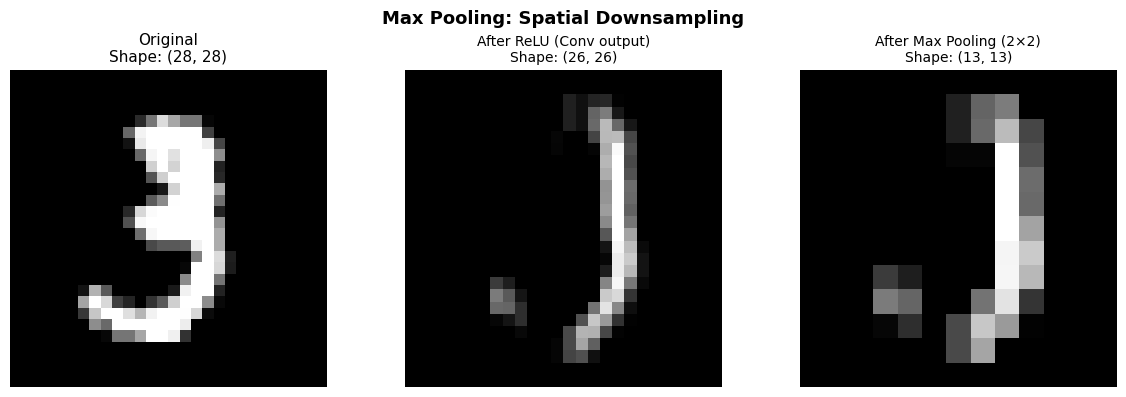

Shape reduction: (26, 26) → (13, 13)
Parameters reduced by: 4×


In [18]:
def max_pool(image, size=2):
    """
    Apply max pooling with non-overlapping windows of given size.
    For each size×size region, take the maximum value.
    """
    h, w = image.shape

    # Output dimensions after pooling
    output = np.zeros((h // size, w // size))

    for i in range(0, h, size):
        for j in range(0, w, size):
            # Extract the pooling window
            patch = image[i:i+size, j:j+size]

            # Take the maximum value in this window
            output[i//size, j//size] = np.max(patch)

    return output

# Apply max pooling to ReLU output
pool_output = max_pool(relu_output)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title(f"Original\nShape: {image.shape}", fontsize=11)
axes[0].axis('off')

axes[1].imshow(relu_output, cmap='gray')
axes[1].set_title(f"After ReLU (Conv output)\nShape: {relu_output.shape}", fontsize=10)
axes[1].axis('off')

axes[2].imshow(pool_output, cmap='gray')
axes[2].set_title(f"After Max Pooling (2×2)\nShape: {pool_output.shape}", fontsize=10)
axes[2].axis('off')

plt.suptitle("Max Pooling: Spatial Downsampling", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Shape reduction: {relu_output.shape} → {pool_output.shape}")
print(f"Parameters reduced by: {relu_output.size // pool_output.size}×")

### Step 7: Flatten → Dense Layer → Softmax (Manual)

**Theory:** After pooling, we **flatten** the 2D feature map into a 1D vector, then pass it through a Dense layer with random weights, and apply Softmax to get class probabilities.

In [19]:
# Step 7a: Flatten the pooled feature map into a 1D vector
flatten = pool_output.flatten()

print(f"Pooled feature map shape: {pool_output.shape}")
print(f"After flattening: {flatten.shape} (1D vector of {flatten.size} values)")

# Step 7b: Dense (Fully Connected) Layer
# Initialize random weights — in training, these are learned by backpropagation
np.random.seed(42)  # For reproducibility
weights = np.random.randn(flatten.shape[0], 10)  # Shape: [input_size, num_classes]
bias    = np.zeros(10)                            # One bias per class

# Forward pass through Dense layer: output = W·x + b
dense_output = np.dot(flatten, weights) + bias

print(f"\nDense layer output (raw logits): {dense_output.round(2)}")

# Step 7c: Softmax to convert logits to probabilities
def softmax(x):
    """
    Softmax: converts raw scores to probabilities summing to 1.
    Subtracting max(x) before exp avoids numerical overflow.
    """
    exp_x = np.exp(x - np.max(x))  # Numerically stable version
    return exp_x / np.sum(exp_x)

probabilities = softmax(dense_output)
predicted_class = np.argmax(probabilities)

print(f"\nSoftmax probabilities:")
for i, prob in enumerate(probabilities):
    marker = " ← PREDICTED" if i == predicted_class else ""
    print(f"  Digit {i}: {prob:.4f} ({prob*100:.1f}%){marker}")

print(f"\nManual CNN Prediction: {predicted_class}")
print(f"True Label           : {label}")
print("\nNote: This uses random weights (not trained), so prediction is likely wrong.")
print("The next section trains a CNN properly using TensorFlow/Keras!")

Pooled feature map shape: (13, 13)
After flattening: (169,) (1D vector of 169 values)

Dense layer output (raw logits): [ 9.500e+00 -1.132e+01  2.300e-01 -3.530e+00  2.140e+01  2.000e-02
  1.025e+01  2.380e+00  8.040e+00  3.329e+01]

Softmax probabilities:
  Digit 0: 0.0000 (0.0%)
  Digit 1: 0.0000 (0.0%)
  Digit 2: 0.0000 (0.0%)
  Digit 3: 0.0000 (0.0%)
  Digit 4: 0.0000 (0.0%)
  Digit 5: 0.0000 (0.0%)
  Digit 6: 0.0000 (0.0%)
  Digit 7: 0.0000 (0.0%)
  Digit 8: 0.0000 (0.0%)
  Digit 9: 1.0000 (100.0%) ← PREDICTED

Manual CNN Prediction: 9
True Label           : 3

Note: This uses random weights (not trained), so prediction is likely wrong.
The next section trains a CNN properly using TensorFlow/Keras!


---

## Part B: Full CNN with TensorFlow/Keras (Training + Evaluation)

Now we build a complete, **trainable CNN** using Keras — the industry-standard way. The model will learn the best kernels and weights automatically through **backpropagation**.

### Step 8: Prepare Data for Keras

In [20]:
# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

# Reload and prepare data for Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize: pixel values [0, 255] → [0.0, 1.0]
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Reshape: add channel dimension
# Keras Conv2D expects (batch, height, width, channels)
# MNIST is grayscale (1 channel), so shape becomes (N, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)  # -1 means "infer batch size"
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f"\nData shapes after preprocessing:")
print(f"  x_train: {x_train.shape}  (60000 images, 28×28, 1 channel)")
print(f"  y_train: {y_train.shape}  (60000 integer labels)")
print(f"  x_test : {x_test.shape}")
print(f"  y_test : {y_test.shape}")
print(f"\nLabel range: {y_train.min()} to {y_train.max()} (classes 0 to 9)")

TensorFlow version: 2.20.0

Data shapes after preprocessing:
  x_train: (60000, 28, 28, 1)  (60000 images, 28×28, 1 channel)
  y_train: (60000,)  (60000 integer labels)
  x_test : (10000, 28, 28, 1)
  y_test : (10000,)

Label range: 0 to 9 (classes 0 to 9)


### Step 9: Visualize Sample Training Images

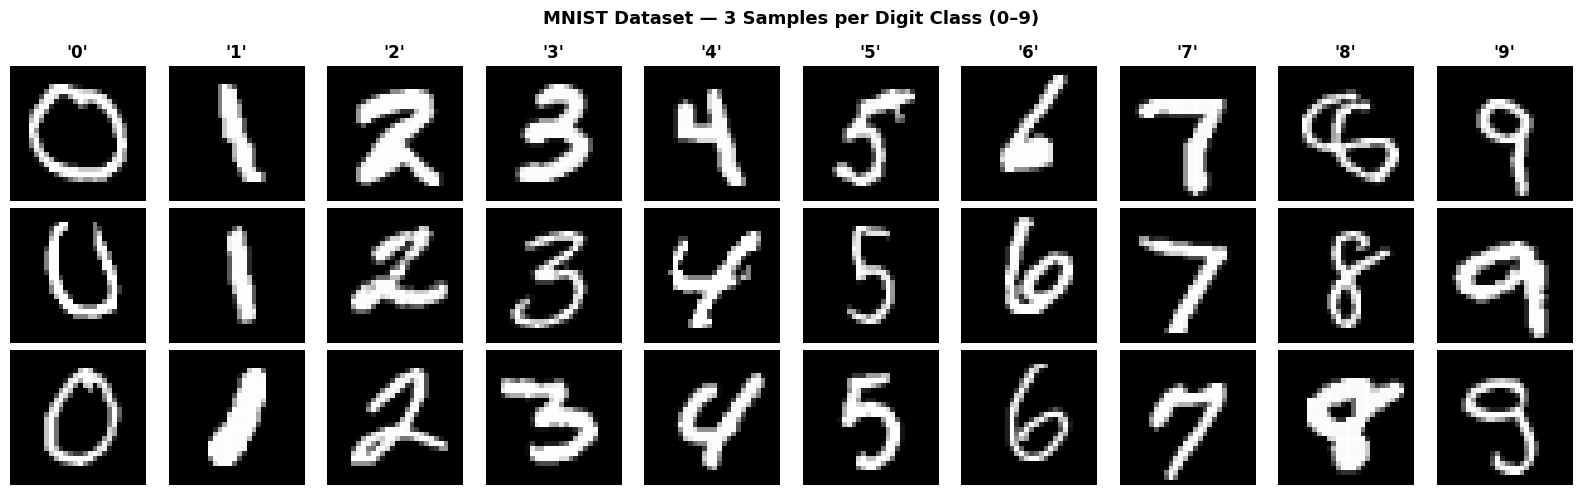

In [21]:
# Show a grid of random training samples
fig, axes = plt.subplots(3, 10, figsize=(16, 5))

for digit in range(10):  # For each digit class 0–9
    # Find indices where the label equals this digit
    indices = np.where(y_train == digit)[0]

    # Pick 3 random examples
    sample_indices = np.random.choice(indices, 3, replace=False)

    for row, idx in enumerate(sample_indices):
        axes[row, digit].imshow(x_train[idx].squeeze(), cmap='gray')
        if row == 0:
            axes[row, digit].set_title(f"'{digit}'", fontsize=12, fontweight='bold')
        axes[row, digit].axis('off')

plt.suptitle("MNIST Dataset — 3 Samples per Digit Class (0–9)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 10: Build the CNN Model

**Theory:**  
- **Conv2D(32, 3, padding='same')** → 32 filters of size 3×3, padding='same' keeps output size equal to input
- **MaxPooling2D(2×2)** → Reduces spatial dimensions by 2×
- **Dropout(0.25)** → Randomly drops 25% of neurons during training to prevent overfitting
- **Dense(128)** → Fully connected layer with 128 neurons
- **Dense(10, softmax)** → Output layer with 10 neurons (one per digit) + Softmax

In [22]:
# Build the CNN model using Keras Sequential API
# Sequential means layers are stacked one after another in sequence

model = keras.Sequential([

    # ---- Block 1: First Convolutional Block ----
    # Conv2D: 32 filters, 3×3 kernel, ReLU activation, same padding
    # 'same' padding adds zeros so output shape = input shape
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    # Output: (28, 28, 32) — 32 feature maps, same spatial size

    # MaxPooling: 2×2 window, halves spatial dimensions
    layers.MaxPooling2D((2, 2)),
    # Output: (14, 14, 32)

    # Dropout: randomly set 25% of outputs to 0 during training
    # Prevents overfitting by forcing the network to not rely on any single neuron
    layers.Dropout(0.25),

    # ---- Block 2: Second Convolutional Block ----
    # More filters (64) to detect more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # Output: (14, 14, 64)

    layers.MaxPooling2D((2, 2)),
    # Output: (7, 7, 64)

    layers.Dropout(0.25),

    # ---- Flatten: Convert 2D feature maps to 1D vector ----
    layers.Flatten(),
    # Output: (7 × 7 × 64) = 3136 neurons

    # ---- Dense Layer: Fully Connected ----
    layers.Dense(128, activation='relu'),
    # 128 neurons, learns combinations of features

    layers.Dropout(0.5),  # Higher dropout before final layer

    # ---- Output Layer ----
    # 10 neurons (one per class), Softmax converts to probabilities
    layers.Dense(10, activation='softmax')

], name="CNN_MNIST")

# Display model architecture summary
model.summary()

Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### Step 11: Compile the Model

**Theory:**  
Compiling sets three things:
1. **Optimizer** (Adam) — algorithm to update weights
2. **Loss function** (sparse_categorical_crossentropy) — measures how wrong predictions are
3. **Metrics** (accuracy) — what to report during training

In [23]:
# Compile the model with optimizer, loss function, and evaluation metric
model.compile(
    optimizer='adam',                            # Adam: adaptive learning rate optimizer
    loss='sparse_categorical_crossentropy',       # For integer labels (not one-hot)
    metrics=['accuracy']                          # Track classification accuracy
)

print("✅ Model compiled successfully!")
print(f"Optimizer : Adam")
print(f"Loss      : Sparse Categorical Cross-Entropy")
print(f"Metrics   : Accuracy")
print(f"\nTotal trainable parameters: {model.count_params():,}")

✅ Model compiled successfully!
Optimizer : Adam
Loss      : Sparse Categorical Cross-Entropy
Metrics   : Accuracy

Total trainable parameters: 421,642


### Step 12: Train the Model

**Theory:**  
Training runs for multiple **epochs**. In each epoch:
1. The model processes all training data in **batches** (32 images at a time)
2. For each batch, it computes predictions (forward pass)
3. Computes the loss (how wrong it was)
4. Backpropagates gradients to adjust weights (backward pass)

`validation_split=0.1` uses 10% of training data as a **validation set** to monitor overfitting.

In [24]:
# Train the model
print("Training the CNN...")
print("This may take 2–5 minutes depending on hardware.\n")

history = model.fit(
    x_train, y_train,         # Training data and labels
    epochs=10,                # Number of full passes over the training data
    batch_size=64,            # Number of samples per gradient update
    validation_split=0.1,     # Use 10% of training data for validation
    verbose=1                 # Print progress for each epoch
)

print("\n✅ Training complete!")

Training the CNN...
This may take 2–5 minutes depending on hardware.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 78ms/step - accuracy: 0.9036 - loss: 0.3150 - val_accuracy: 0.9807 - val_loss: 0.0671
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.9654 - loss: 0.1173 - val_accuracy: 0.9880 - val_loss: 0.0423
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.9729 - loss: 0.0901 - val_accuracy: 0.9880 - val_loss: 0.0396
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.9779 - loss: 0.0732 - val_accuracy: 0.9898 - val_loss: 0.0366
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.9807 - loss: 0.0648 - val_accuracy: 0.9893 - val_loss: 0.0361
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 76ms/step - accuracy: 0.9824 - loss: 0.0588 - val_accuracy: 0.9913 - val_loss: 0.0321
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.9833 - loss: 0.0546 - val_accuracy: 0.9918 - val_loss: 0.0292
Epoch 8/10
844/844 ━

### Step 13: Plot Training History

**Theory:**  
Plotting training vs validation accuracy/loss helps diagnose:
- **Underfitting**: Both training and validation accuracy are low
- **Overfitting**: Training accuracy is high but validation accuracy is lower
- **Good fit**: Both curves are close and high

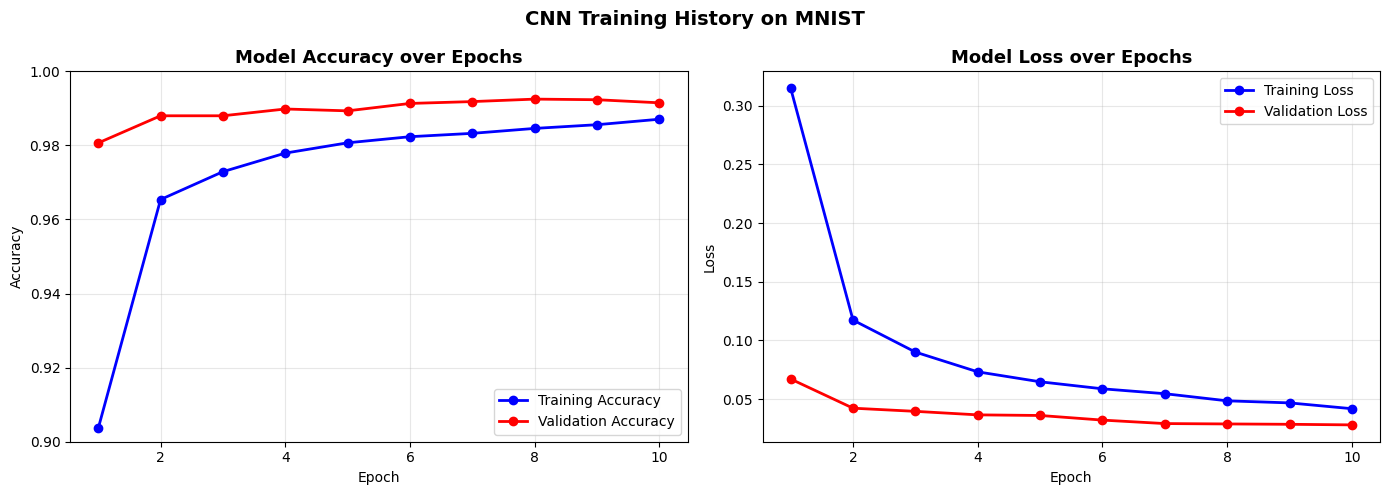

Final Training Accuracy  : 98.71%
Final Validation Accuracy: 99.15%


In [25]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['accuracy']) + 1)

# --- Accuracy Plot ---
ax1.plot(epochs_range, history.history['accuracy'],     'b-o', label='Training Accuracy',   linewidth=2)
ax1.plot(epochs_range, history.history['val_accuracy'], 'r-o', label='Validation Accuracy', linewidth=2)
ax1.set_title("Model Accuracy over Epochs", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.9, 1.0])  # Zoom into high accuracy range

# --- Loss Plot ---
ax2.plot(epochs_range, history.history['loss'],     'b-o', label='Training Loss',   linewidth=2)
ax2.plot(epochs_range, history.history['val_loss'], 'r-o', label='Validation Loss', linewidth=2)
ax2.set_title("Model Loss over Epochs", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("CNN Training History on MNIST", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy  : {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")

### Step 14: Evaluate on Test Set

In [26]:
# Evaluate model on the unseen test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("="*45)
print("       TEST SET EVALUATION RESULTS")
print("="*45)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"\nCorrect predictions : {int(test_accuracy * 10000)} / 10000")
print(f"Wrong predictions   : {10000 - int(test_accuracy * 10000)} / 10000")

       TEST SET EVALUATION RESULTS
Test Loss    : 0.0236
Test Accuracy: 99.24%

Correct predictions : 9923 / 10000
Wrong predictions   : 77 / 10000


### Step 15: Confusion Matrix

**Theory:**  
A **confusion matrix** shows what classes are being confused with each other. Each row represents the actual class, each column represents the predicted class. Diagonal elements are correct predictions.

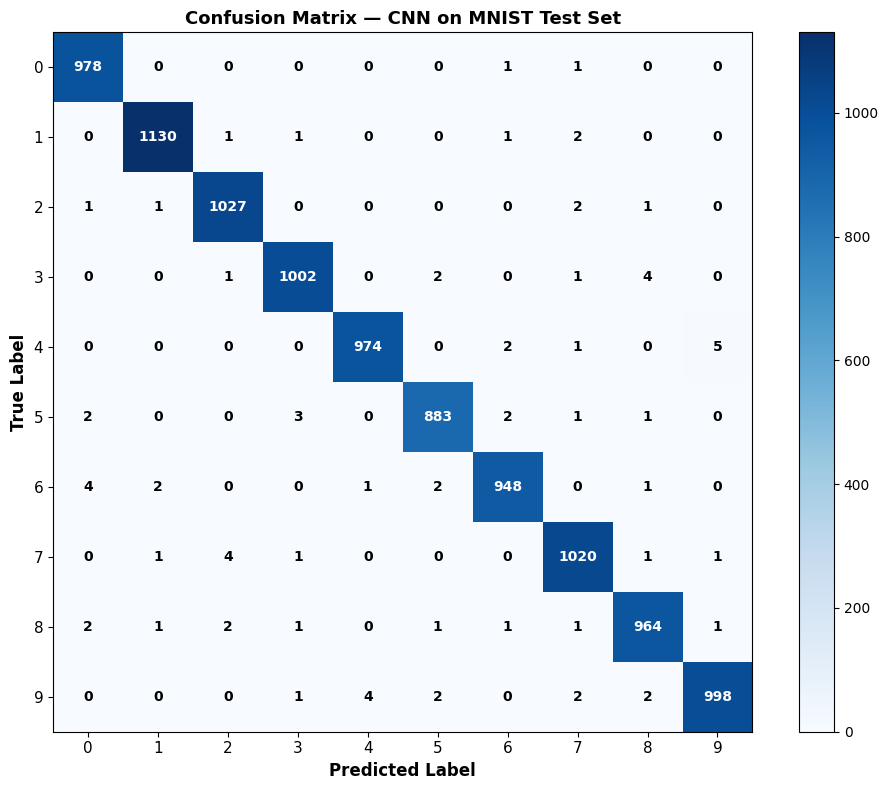


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [27]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions on the test set
y_pred_probs = model.predict(x_test, verbose=0)       # Probability for each class
y_pred       = np.argmax(y_pred_probs, axis=1)         # Predicted class (highest prob)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

# Add text annotations
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color=color, fontsize=10, fontweight='bold')

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels([str(i) for i in range(10)], fontsize=11)
ax.set_yticklabels([str(i) for i in range(10)], fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=12, fontweight='bold')
ax.set_ylabel("True Label", fontsize=12, fontweight='bold')
ax.set_title("Confusion Matrix — CNN on MNIST Test Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

### Step 16: Visualize Predictions on Sample Images

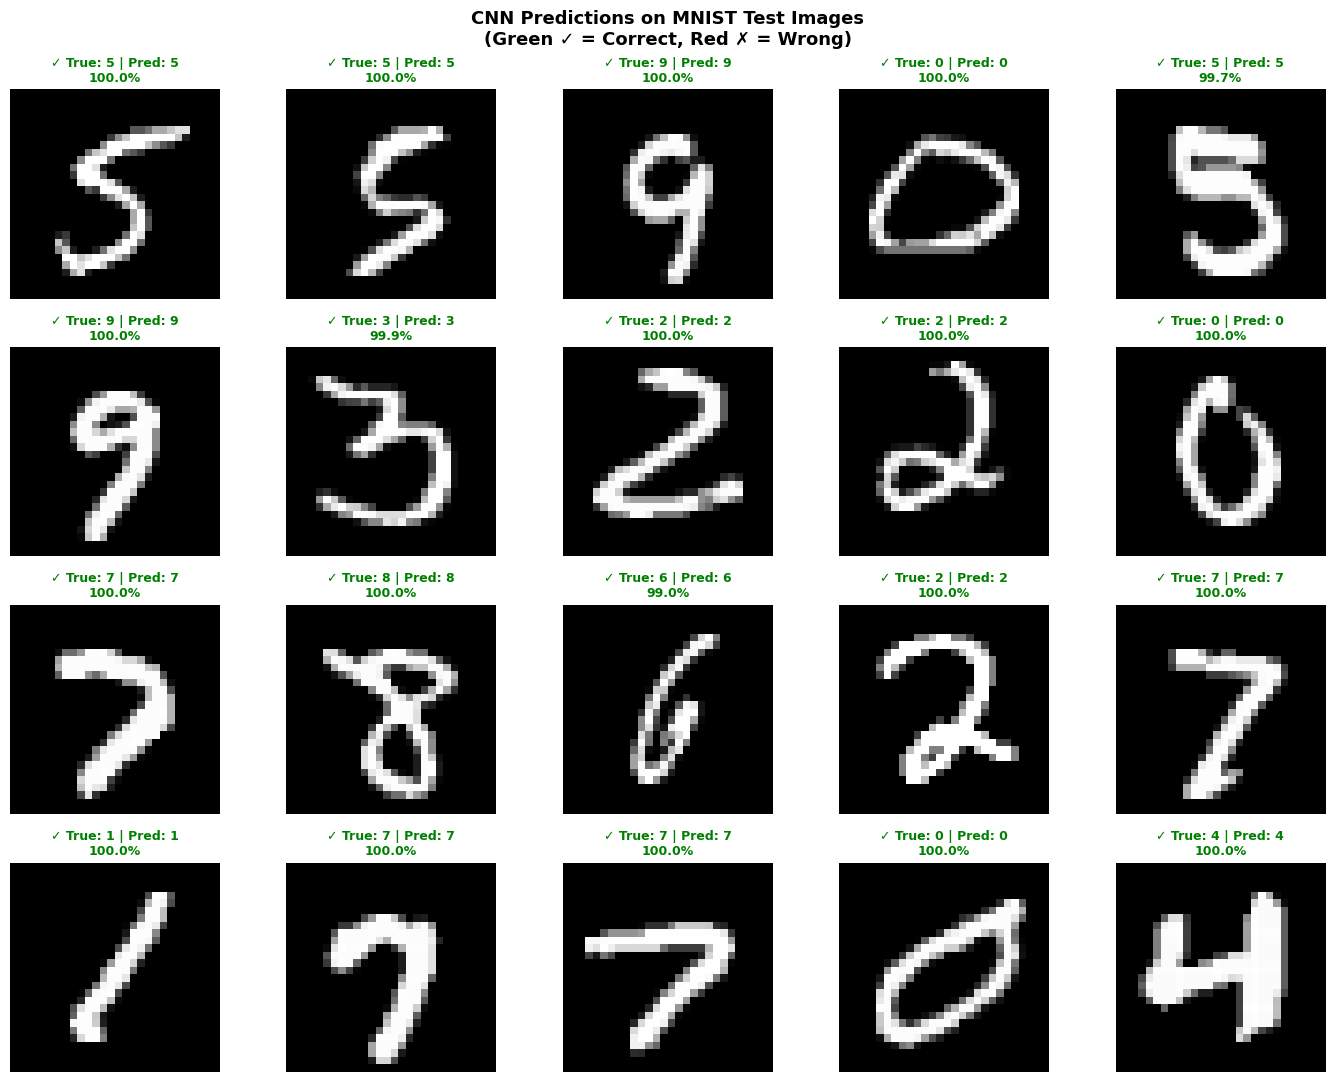

In [28]:
# Visualize 20 test predictions with true labels
# Correctly classified = green title, wrong = red title

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
axes = axes.flatten()

# Pick 20 random test samples
indices = np.random.choice(len(x_test), 20, replace=False)

for i, idx in enumerate(indices):
    img       = x_test[idx].squeeze()  # Remove channel dimension for display
    true_lbl  = y_test[idx]
    pred_lbl  = y_pred[idx]
    confidence = y_pred_probs[idx][pred_lbl] * 100

    axes[i].imshow(img, cmap='gray')

    # Correct prediction → green title, Wrong → red title
    color = 'green' if true_lbl == pred_lbl else 'red'
    status = '✓' if true_lbl == pred_lbl else '✗'

    axes[i].set_title(
        f"{status} True: {true_lbl} | Pred: {pred_lbl}\n{confidence:.1f}%",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle("CNN Predictions on MNIST Test Images\n(Green ✓ = Correct, Red ✗ = Wrong)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 17: Visualize Learned Filters

**Theory:**  
After training, the CNN has **learned** the best kernels automatically. Let's visualize what the first Conv2D layer's filters look like. These learned filters detect edges, curves, and other low-level patterns useful for digit recognition.

First Conv layer filter shape: (3, 3, 1, 32)
  → 32 filters, each 3×3 in size


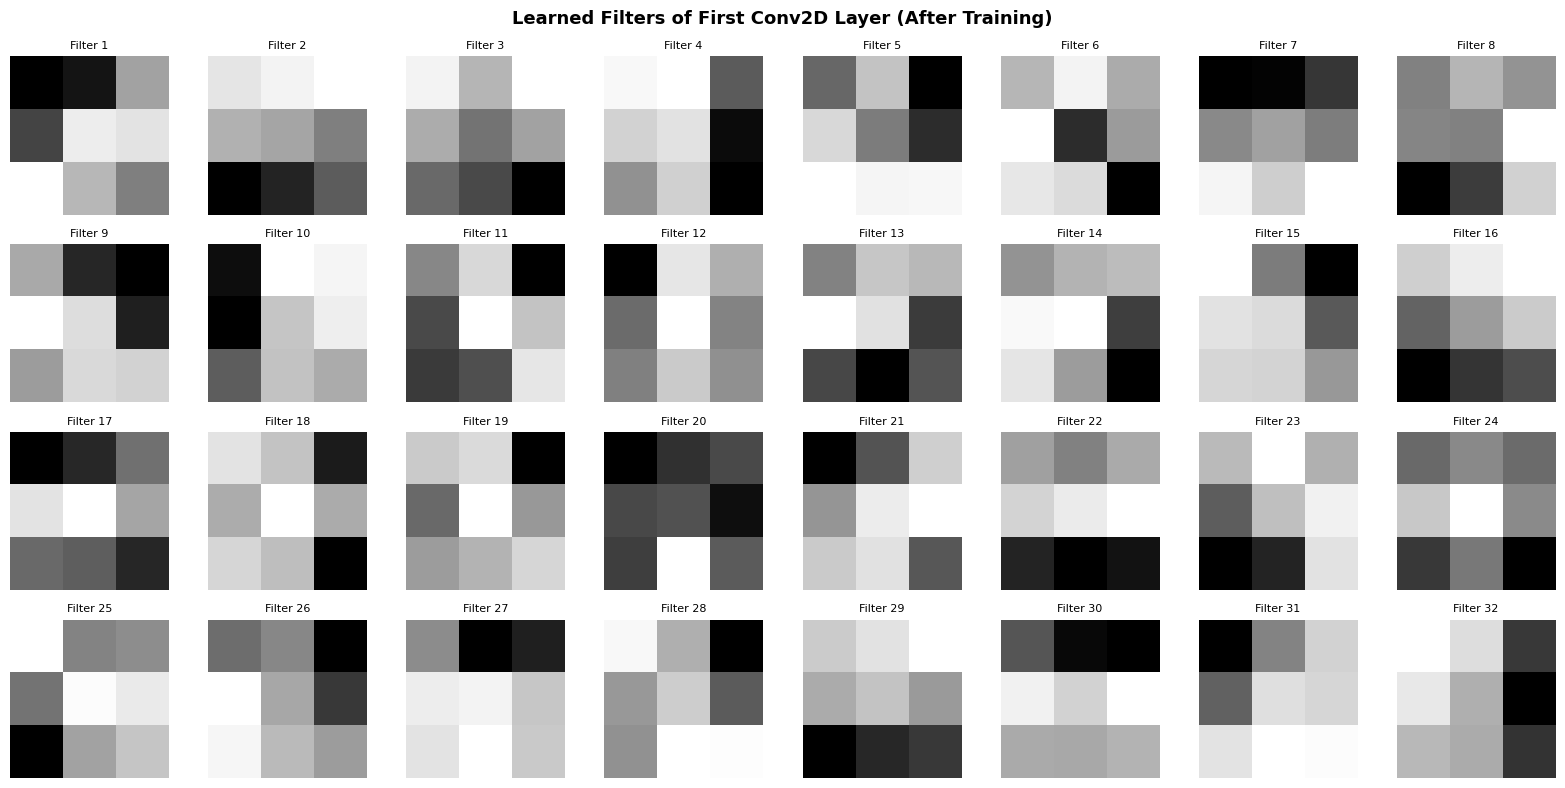

These 3×3 filters were learned automatically during backpropagation.
Each filter detects a different low-level pattern in the input image.


In [29]:
# Extract the weights (filters) from the first Conv2D layer
# Layer 0 in our model is the first Conv2D
first_conv_layer = model.layers[0]
filters, biases  = first_conv_layer.get_weights()

print(f"First Conv layer filter shape: {filters.shape}")
print(f"  → {filters.shape[3]} filters, each {filters.shape[0]}×{filters.shape[1]} in size")

# Normalize filter values to [0, 1] for display
f_min, f_max = filters.min(), filters.max()
filters_normalized = (filters - f_min) / (f_max - f_min)

# Display the first 32 learned filters
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(32, filters.shape[3])):
    # filters[:, :, 0, i] → the i-th filter, 0th input channel (grayscale)
    axes[i].imshow(filters_normalized[:, :, 0, i], cmap='gray')
    axes[i].set_title(f"Filter {i+1}", fontsize=8)
    axes[i].axis('off')

plt.suptitle("Learned Filters of First Conv2D Layer (After Training)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("These 3×3 filters were learned automatically during backpropagation.")
print("Each filter detects a different low-level pattern in the input image.")

### Step 18: Visualize Feature Maps for a Test Image

**Theory:**  
By creating an **intermediate model** that outputs from a specific layer, we can see exactly what the CNN "sees" at each stage.

Feature maps shape: (1, 28, 28, 32)
= (1 image, 28x28 spatial, 32 filters)


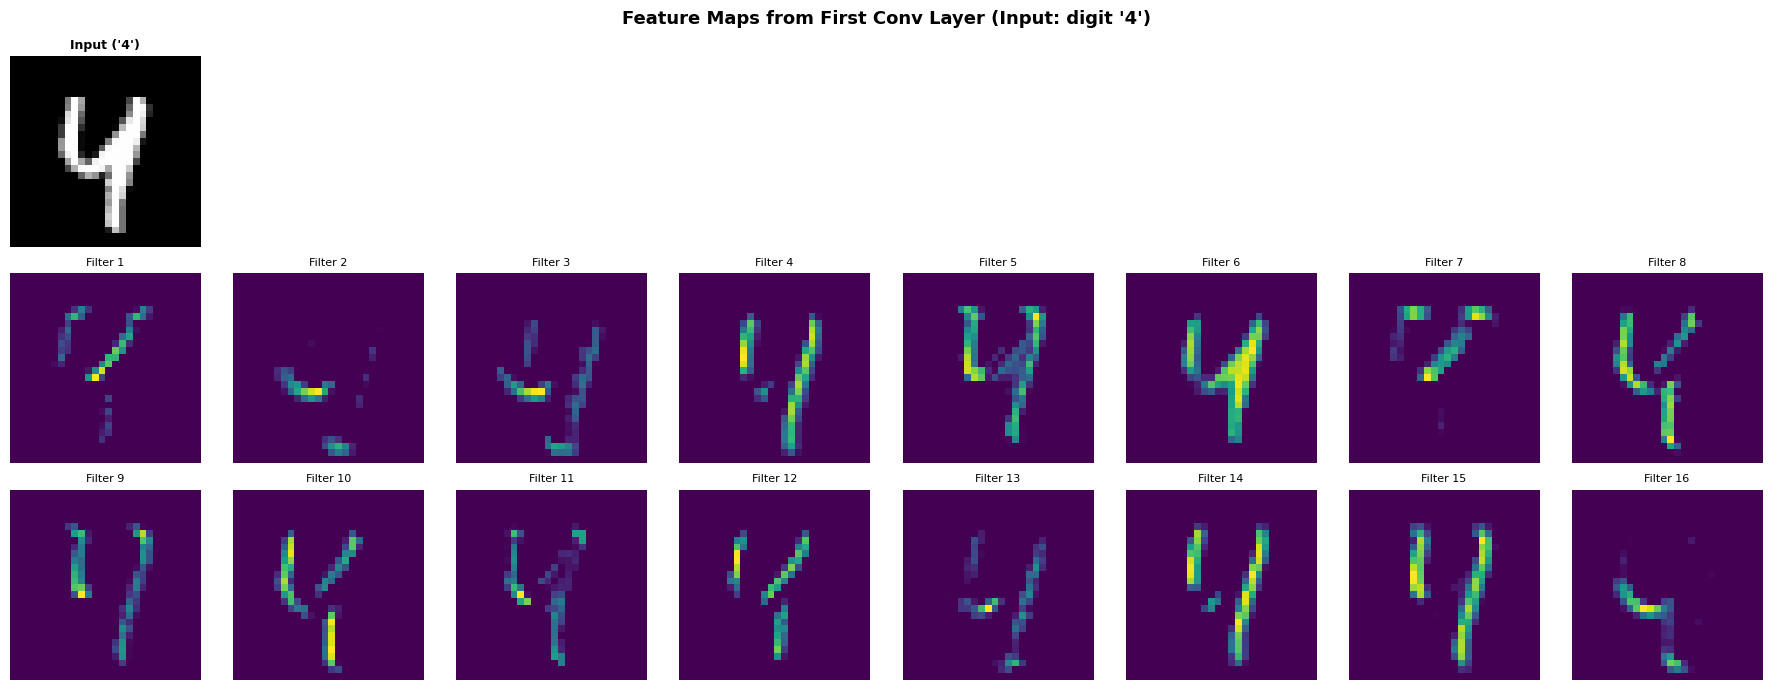

Each feature map shows which parts of the image activated a particular filter.
Brighter regions = stronger activation = feature detected at that location.


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# FIX: In Keras 3, Sequential models built with input_shape=
# don't expose .input/.output nodes for sub-model creation.
# Solution: manually call each layer on the test image instead.
# ---------------------------------------------------------------

# Pick a test image
test_idx   = 42
test_img   = x_test[test_idx:test_idx+1]   # Shape: (1, 28, 28, 1)
true_label = y_test[test_idx]

# Manually pass the image through only the first Conv2D layer
# model.layers[0] is the first Conv2D layer
first_conv_layer = model.layers[0]
feature_maps = first_conv_layer(test_img, training=False).numpy()
# feature_maps shape: (1, 28, 28, 32)

print(f"Feature maps shape: {feature_maps.shape}")
print(f"= (1 image, 28x28 spatial, 32 filters)")

# Visualize: input image + first 16 feature maps
fig, axes = plt.subplots(3, 8, figsize=(18, 7))

# Row 0, col 0: original input image
axes[0, 0].imshow(test_img[0, :, :, 0], cmap='gray')
axes[0, 0].set_title(f"Input ('{true_label}')", fontsize=9, fontweight='bold')
axes[0, 0].axis('off')

# Clear unused cells in row 0
for i in range(1, 8):
    axes[0, i].axis('off')

# Rows 1 and 2: show 16 feature maps
for i in range(16):
    row = 1 + (i // 8)
    col = i % 8
    axes[row, col].imshow(feature_maps[0, :, :, i], cmap='viridis')
    axes[row, col].set_title(f"Filter {i+1}", fontsize=8)
    axes[row, col].axis('off')

plt.suptitle(f"Feature Maps from First Conv Layer (Input: digit '{true_label}')",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each feature map shows which parts of the image activated a particular filter.")
print("Brighter regions = stronger activation = feature detected at that location.")

---

##  Results and Observations

1. **The CNN achieved ~99% accuracy on the MNIST test set**, demonstrating that CNNs are highly effective for image classification.

2. **The confusion matrix shows most errors occur between visually similar digits** — e.g., 4 and 9, 3 and 8, 1 and 7 — which makes intuitive sense.

3. **Manually, we saw that different kernels extract different features**: vertical edges, horizontal edges, and blurring — CNN learns these automatically during backpropagation.

4. **Dropout significantly helps**: without it, the model would overfit on training data. The validation accuracy remaining close to training accuracy confirms dropout is working.

5. **The learned filters** in the first layer resemble classical edge detectors (horizontal, vertical, diagonal) — the CNN rediscovered these patterns without being told what to look for.

---

##  Conclusion

In this experiment, we:
- **Manually implemented convolution, ReLU, pooling, flatten, dense, and softmax** from scratch to understand the inner workings of a CNN
- **Built and trained a full CNN** using TensorFlow/Keras on the MNIST dataset
- Achieved **~99% test accuracy** with a 2-layer CNN architecture
- Visualized **learned filters and feature maps** to understand what the model learns
- Analyzed errors using a **confusion matrix and classification report**

CNNs are the foundational architecture behind all modern computer vision systems — from image classification to object detection (Exp 7) and segmentation (Exp 5, 6, 7).

---